In [64]:
import unittest
import numpy as np
import board
import game
import minimax
import tt
import time
import matplotlib.pyplot as plt

In [65]:
def setUp(self):
        self.board = board.Board(10)

In [66]:
class TestGomokuBoard(unittest.TestCase):
    
    def setUp(self):
        self.board = board.Board(10)

    def test_SC9_dynamic_dimensions(self):
        board_10 = board.Board(10)
        board_15 = board.Board(15)
        
        self.assertEqual(board_10.board_array.shape, (10, 10))
        self.assertEqual(board_15.board_array.shape, (15, 15))

    def test_SC10_encapsulated_state_changes(self):
        self.board.change_state(5, 5, 1)
        self.assertEqual(self.board.board_array[5][5], 1)
        
        with self.assertRaises(IndexError):
            self.board.change_state(11, 11, 1)
            
        with self.assertRaises(ValueError):
            self.board.change_state(0, 0, 99)

    def test_SC11_detect_draw(self):
        self.assertFalse(self.board.check_draw())
        self.board.empty_count = 0
        self.assertTrue(self.board.check_draw())

    def test_SC12_detect_win_state(self):
        self.board.change_state(0, 0, 1)
        self.board.change_state(0, 1, 1)
        self.board.change_state(0, 2, 1)
        self.board.change_state(0, 3, 1)
        
        self.board.change_state(0, 4, 1)
        is_win = self.board.check_win_from(0, 4, 1)
        self.assertTrue(is_win, "Board failed to detect a horizontal 5-in-a-row")

In [67]:
class TestGameFlow(unittest.TestCase):
    
    def test_SC13_turn_alternation(self):
        test_game = game.Game(10)
        self.assertEqual(test_game.current_player.piece, 1)
        
        test_game.make_move(5, 5)
        self.assertEqual(test_game.current_player.piece, 2)
        
        test_game.make_move(6, 6)
        self.assertEqual(test_game.current_player.piece, 1)

In [68]:
class TestAILogic(unittest.TestCase):
    
    def test_SC18_move_filtering(self):
        test_board = board.Board(10)
        test_board.change_state(5, 5, 1)
        
        filtered_moves = minimax.move_filter(test_board, radius=1)
        self.assertTrue(len(filtered_moves) <= 9, "Move filter is not stripping away irrelevant empty squares.")
        self.assertIn((4, 4), filtered_moves, "Move filter missed a valid adjacent square.")

    def test_SC22_transposition_table(self):
        board_A = board.Board(10)
        board_B = board.Board(10)
        
        board_A.change_state(5, 5, 1)
        board_A.change_state(6, 6, 2)
        
        board_B.change_state(6, 6, 2)
        board_B.change_state(5, 5, 1)
        
        self.assertTrue(np.array_equal(board_A.board_array, board_B.board_array))
        
        hash_A = tt.key(board_A.current_hash, 1)
        hash_B = tt.key(board_B.current_hash, 1)
        self.assertEqual(hash_A, hash_B, "Transposition table keys do not match for identical board states.")

    def test_SC15_16_17_20_complex_board(self):
        b = board.Board(10)
        ai = game.Player("ai", 2)
        tt.clear()
        
        for c in range(2, 6): b.change_state(2, c, 2)
        for r in range(5, 8): b.change_state(r, 5, 1)
        b.change_state(6, 6, 2)
        b.change_state(7, 7, 1)
        
        moves = {
            "Terminal Win": (2, 6),
            "Critical Block": (4, 5),
            "Positional": (5, 6),
            "Isolated": (0, 0)
        }
        
        results = []
        for name, pos in moves.items():
            own_score = minimax.total_move_score(b, pos[0], pos[1], 2)
            opp_score = minimax.total_move_score(b, pos[0], pos[1], 1)
            total = own_score + opp_score
            results.append((total, pos, name))
            
        best = ai.policy(b)
        print("\n--- SC15,16,17,20: Complex Board Evaluation ---")
        print("\nMove Comparison:")
        for score, pos, name in sorted(results, key=lambda x: x[0], reverse=True):
            mark = "SELECTED" if pos == best else ""
            print(f"{name:<15} {str(pos):<8} Score: {score:<8} {mark}")
            
        self.assertIn(best, [(2, 1), (2, 6)])

    def test_SC23_bounded_tt(self):
        original_max = tt.MAX_TT_SIZE 
        tt.MAX_TT_SIZE = 100 
        
        tt.clear()
        for i in range(200):
            tt.store(hash_key=i, depth=1, alpha0=-1000, beta0=1000, score=10)
        self.assertTrue(len(tt.TT) <= 100, "Transposition table exceeded its memory bounds!")
        tt.MAX_TT_SIZE = original_max
        tt.clear()

In [69]:
def plot_performance_comparison(seq_times, par_times):
    state_labels = [f"State {i+1}" for i in range(len(seq_times))]
    

    x = range(len(state_labels))
    width = 0.35 

    fig, ax = plt.subplots(figsize=(8, 5))
    
    ax.bar([pos - width/2 for pos in x], seq_times, width, label='Sequential', color='#1f77b4')
    ax.bar([pos + width/2 for pos in x], par_times, width, label='Parallel', color='#ff7f0e')

    ax.set_ylabel('Execution Time (seconds)', fontweight='bold')
    ax.set_title('SC26: Sequential vs. Parallel Performance', fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(state_labels)
    ax.legend()
    
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

In [70]:
def plot_adaptive_depth_times(time_2, time_3, time_4):
    depths = ['Depth 2', 'Depth 3', 'Depth 4']
    times = [time_2, time_3, time_4]
    
    fig, ax = plt.subplots(figsize=(7, 5))
    
    bars = ax.bar(depths, times, color=['#2ca02c', '#ff7f0e', '#d62728'])
    
    ax.set_ylabel('Execution Time (seconds)', fontweight='bold')
    ax.set_title('SC21: Execution Time by Search Depth', fontweight='bold', pad=15)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                f'{height:.2f}s', 
                ha='center', va='bottom', fontweight='bold')
        
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [71]:
class TestTime(unittest.TestCase):
    
    def setUp(self):
        self.test_board = board.Board(10)
        self.ai_player = game.Player("ai", 2)
        
        self.test_board.change_state(5, 5, 1)
        self.test_board.change_state(5, 6, 2)
        self.test_board.change_state(6, 5, 1)

    def test_SC19_alpha_beta_pruning_efficiency(self):
        minimax.DEFAULT_CONFIG.max_depth = 4 
        
        original_change_state = board.Board.change_state
        nodes_evaluated = 0
        
        def counted_change_state(self, x, y, piece):
            nonlocal nodes_evaluated
            if piece != 0: 
                nodes_evaluated += 1
            return original_change_state(self, x, y, piece)
            
        board.Board.change_state = counted_change_state
        self.ai_player.policy(self.test_board)
        board.Board.change_state = original_change_state
        
        self.assertTrue(nodes_evaluated < 100000)
        print(f"\n[SC19] Nodes evaluated: {nodes_evaluated} (Theoretical unpruned: 100!~=94,000,000)")

    def test_SC21_adaptive_depth_time(self):
        print("\n--- SC21: Adaptive Depth Execution Times ---")

        global time_depth_2
        global time_depth_3
        global time_depth_4

        minimax.DEFAULT_CONFIG.max_depth = 2
        start_2 = time.time()
        self.ai_player.policy(self.test_board)
        time_depth_2 = time.time() - start_2
        

        minimax.DEFAULT_CONFIG.max_depth = 3
        start_3 = time.time()
        self.ai_player.policy(self.test_board)
        time_depth_3 = time.time() - start_3
        

        minimax.DEFAULT_CONFIG.max_depth = 4
        start_4 = time.time()
        self.ai_player.policy(self.test_board)
        time_depth_4 = time.time() - start_4
        

        self.assertTrue(time_depth_3 > time_depth_2)
        self.assertTrue(time_depth_4 > time_depth_3)
        self.assertTrue(time_depth_4 < 15.0)
        
        print(f"[SC21] Depth 2: {time_depth_2:.4f}s | Depth 3: {time_depth_3:.4f}s | Depth 4: {time_depth_4:.4f}s")

    def test_SC26_resource_configuration(self):
        print("\n--- SC26: Parallel Processing Efficiency (Mean over Multiple States) ---")
        
        global seq_times
        global par_times
        
        state_1 = board.Board(10)
        state_1.change_state(5, 5, 1)
        state_1.change_state(5, 6, 2)

        state_2 = board.Board(10)
        for r, c in [(4,4), (4,5), (5,4), (5,5), (6,6)]:
            state_2.change_state(r, c, 1 if (r + c) % 2 == 0 else 2)

        state_3 = board.Board(10)
        for i in range(3):
            state_3.change_state(3, 3 + i, 1)
            state_3.change_state(7, 3 + i, 2)

        test_states = [state_1, state_2, state_3]
        minimax.DEFAULT_CONFIG.max_depth = 4
        
        seq_times = []
        minimax.DEFAULT_CONFIG.parallel = False
        minimax.DEFAULT_CONFIG.max_cores = 1
        
        for state in test_states:
            start = time.time()
            self.ai_player.policy(state)
            seq_times.append(time.time() - start)

        par_times = []
        minimax.DEFAULT_CONFIG.parallel = True
        minimax.DEFAULT_CONFIG.max_cores = 4 
        
        for state in test_states:
            start = time.time()
            self.ai_player.policy(state)
            par_times.append(time.time() - start)

        mean_seq = sum(seq_times) / len(seq_times)
        mean_par = sum(par_times) / len(par_times)
        reduction = ((mean_seq - mean_par) / mean_seq) * 100

        print(f"[SC26] Mean Sequential Time: {mean_seq:.4f}s")
        print(f"[SC26] Mean Parallel Time: {mean_par:.4f}s")
        print(f"[SC26] Average Time Reduction: {reduction:.1f}%")

        self.assertGreater(mean_seq, mean_par)
        self.assertGreater(reduction, 0)

test_SC15_16_17_20_complex_board (__main__.TestAILogic) ... ok
test_SC18_move_filtering (__main__.TestAILogic) ... ok
test_SC22_transposition_table (__main__.TestAILogic) ... ok
test_SC23_bounded_tt (__main__.TestAILogic) ... ok
test_SC13_turn_alternation (__main__.TestGameFlow) ... ok
test_SC10_encapsulated_state_changes (__main__.TestGomokuBoard) ... ok
test_SC11_detect_draw (__main__.TestGomokuBoard) ... ok
test_SC12_detect_win_state (__main__.TestGomokuBoard) ... ok
test_SC9_dynamic_dimensions (__main__.TestGomokuBoard) ... ok
test_SC19_alpha_beta_pruning_efficiency (__main__.TestTime) ... 


--- SC15,16,17,20: Complex Board Evaluation ---

Move Comparison:
Terminal Win    (2, 6)   Score: 999992   
Critical Block  (4, 5)   Score: 99998    
Positional      (5, 6)   Score: 358      
Isolated        (0, 0)   Score: -20      


ok
test_SC21_adaptive_depth_time (__main__.TestTime) ... 


[SC19] Nodes evaluated: 24 (Theoretical unpruned: 100!~=94,000,000)

--- SC21: Adaptive Depth Execution Times ---


ok
test_SC26_resource_configuration (__main__.TestTime) ... 

[SC21] Depth 2: 0.3097s | Depth 3: 0.4258s | Depth 4: 0.6186s

--- SC26: Parallel Processing Efficiency (Mean over Multiple States) ---
[SC26] Mean Sequential Time: 1.1718s
[SC26] Mean Parallel Time: 0.6688s
[SC26] Average Time Reduction: 42.9%


ok

----------------------------------------------------------------------
Ran 12 tests in 7.958s

OK


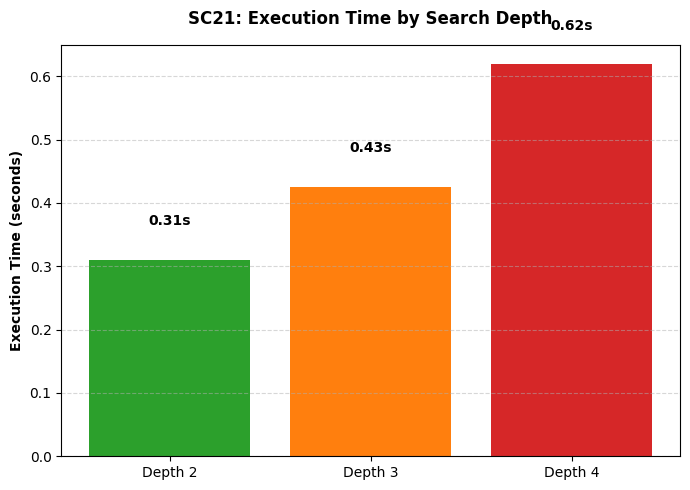

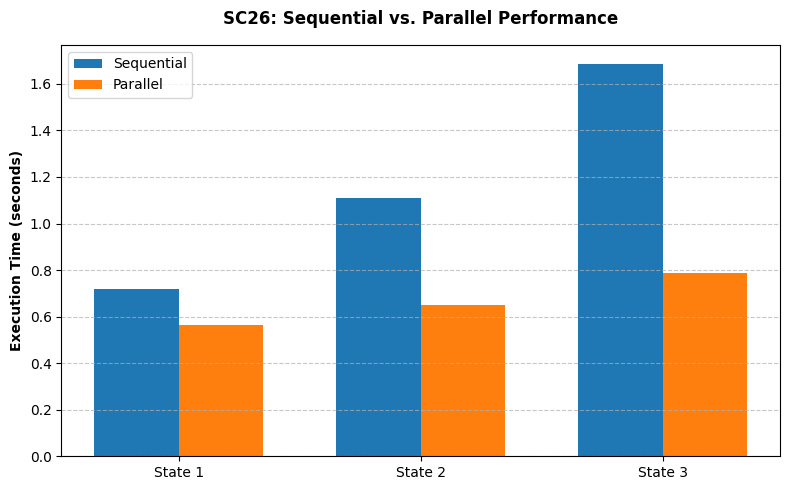

In [72]:
if __name__ == '__main__':
    unittest.main(argv=[''], exit=False, verbosity=2)
    plot_adaptive_depth_times(time_depth_2, time_depth_3, time_depth_4)
    plot_performance_comparison(seq_times, par_times)